In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [ ]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'




In [ ]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [ ]:
mertz = [144.25,-67.5]

In [ ]:
lwe_ds = GRACE().ds
sla = SLA(deg=0.25).da
dot_ds = DOT().ds

In [8]:
elevation_ = GEBCO(coarsen_factor=10).ds.elevation
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__

In [ ]:
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

In [23]:
extent_totten =[118,119.5, -66.5,-65.5] # no data before 2015??
extent_vincennes = [106,108.5,-66.5,-64.5]
extent = extent_vincennes

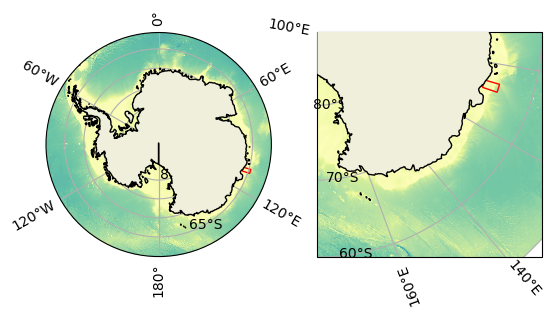

In [24]:
fig, ax = plt.subplots(1,2,subplot_kw={"projection":ccrs.SouthPolarStereo()})
pfns.sp(ax[0],elevation_,sea='Small Southern Ocean')
extent = extent
ax[0].add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))
pfns.sp(ax[1],elevation_,extent=[90,180,-80,-60])
ax[1].add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))

In [25]:
# crop elevation
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))

In [26]:
meop=MEOP(extent=extent)

In [27]:
meop.load_profiles(full=True)

  0%|          | 0/73 [00:00<?, ?it/s]

100%|██████████| 73/73 [01:00<00:00,  1.20it/s]


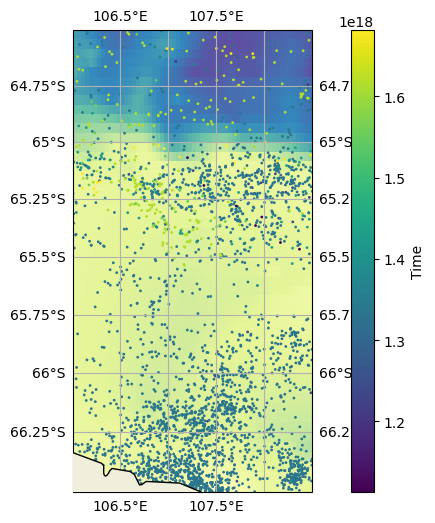

In [28]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax=ax,da=elevation,extent=extent)
im=ax.scatter(meop.df.longitude, meop.df.latitude, [1 for t in meop.df.index], meop.df.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')


In [29]:
sha_cropped = crop_to_extent(sha_ds_sla,extent)
meop.grid_profiles(sha_cropped.longitude.to_numpy(),sha_cropped.latitude.to_numpy())

100%|██████████| 11/11 [00:01<00:00, 10.60it/s]


merging...


In [30]:
# SINGLE DS WITH GRIDDED SHA and GPH FOR MRTZ
sha_gph_ = xr.merge([sha_cropped.where(sha_cropped.time > meop.gridded_profiles.time[0],drop=True),
                     meop.gridded_profiles.where(meop.gridded_profiles.time < sha_cropped.time[-1],drop=True)])


In [31]:
sha_gph_

<xarray.Dataset> Size: 2MB
Dimensions:            (longitude: 11, latitude: 9, time: 201)
Coordinates:
  * longitude          (longitude) float64 88B 106.0 106.2 106.5 ... 108.2 108.5
  * latitude           (latitude) float64 72B -66.5 -66.25 ... -64.75 -64.5
  * time               (time) datetime64[ns] 2kB 2005-04-01 ... 2021-12-01
Data variables:
    ssh                (time, latitude, longitude) float64 159kB nan ... -1.633
    lwe                (time, latitude, longitude) float64 159kB nan ... 2.872
    msl                (time, latitude, longitude) float64 159kB nan nan ... nan
    msla               (time, latitude, longitude) float64 159kB nan nan ... nan
    ssha               (time, latitude, longitude) float64 159kB nan ... -1.851
    eha                (time, latitude, longitude) float64 159kB nan ... 1.408
    sha                (time, latitude, longitude) float64 159kB nan ... -3.073
    profile_gph        (longitude, latitude, time) float64 159kB nan nan ... nan
    profile_latitude   (longitude, latitude, time) float64 159kB nan nan ... nan
    profile_longitude  (longitude, latitude, time) float64 159kB nan nan ... nan
    profile_cnt        (longitude, latitude, time) float64 159kB nan nan ... nan

In [32]:
profile_gph_ungridded = meop.df.dropna().gph.groupby(pd.Grouper(freq='MS')).mean().to_xarray().rename({'index':'time'})

In [33]:
sha_gph_['profile_gpha'] = 100*(sha_gph_.profile_gph - sha_gph_.profile_gph.mean('time'))

In [34]:
sha_gph_.profile_cnt.sum()

<xarray.DataArray 'profile_cnt' ()> Size: 8B
array(2731.)

Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Rendering..


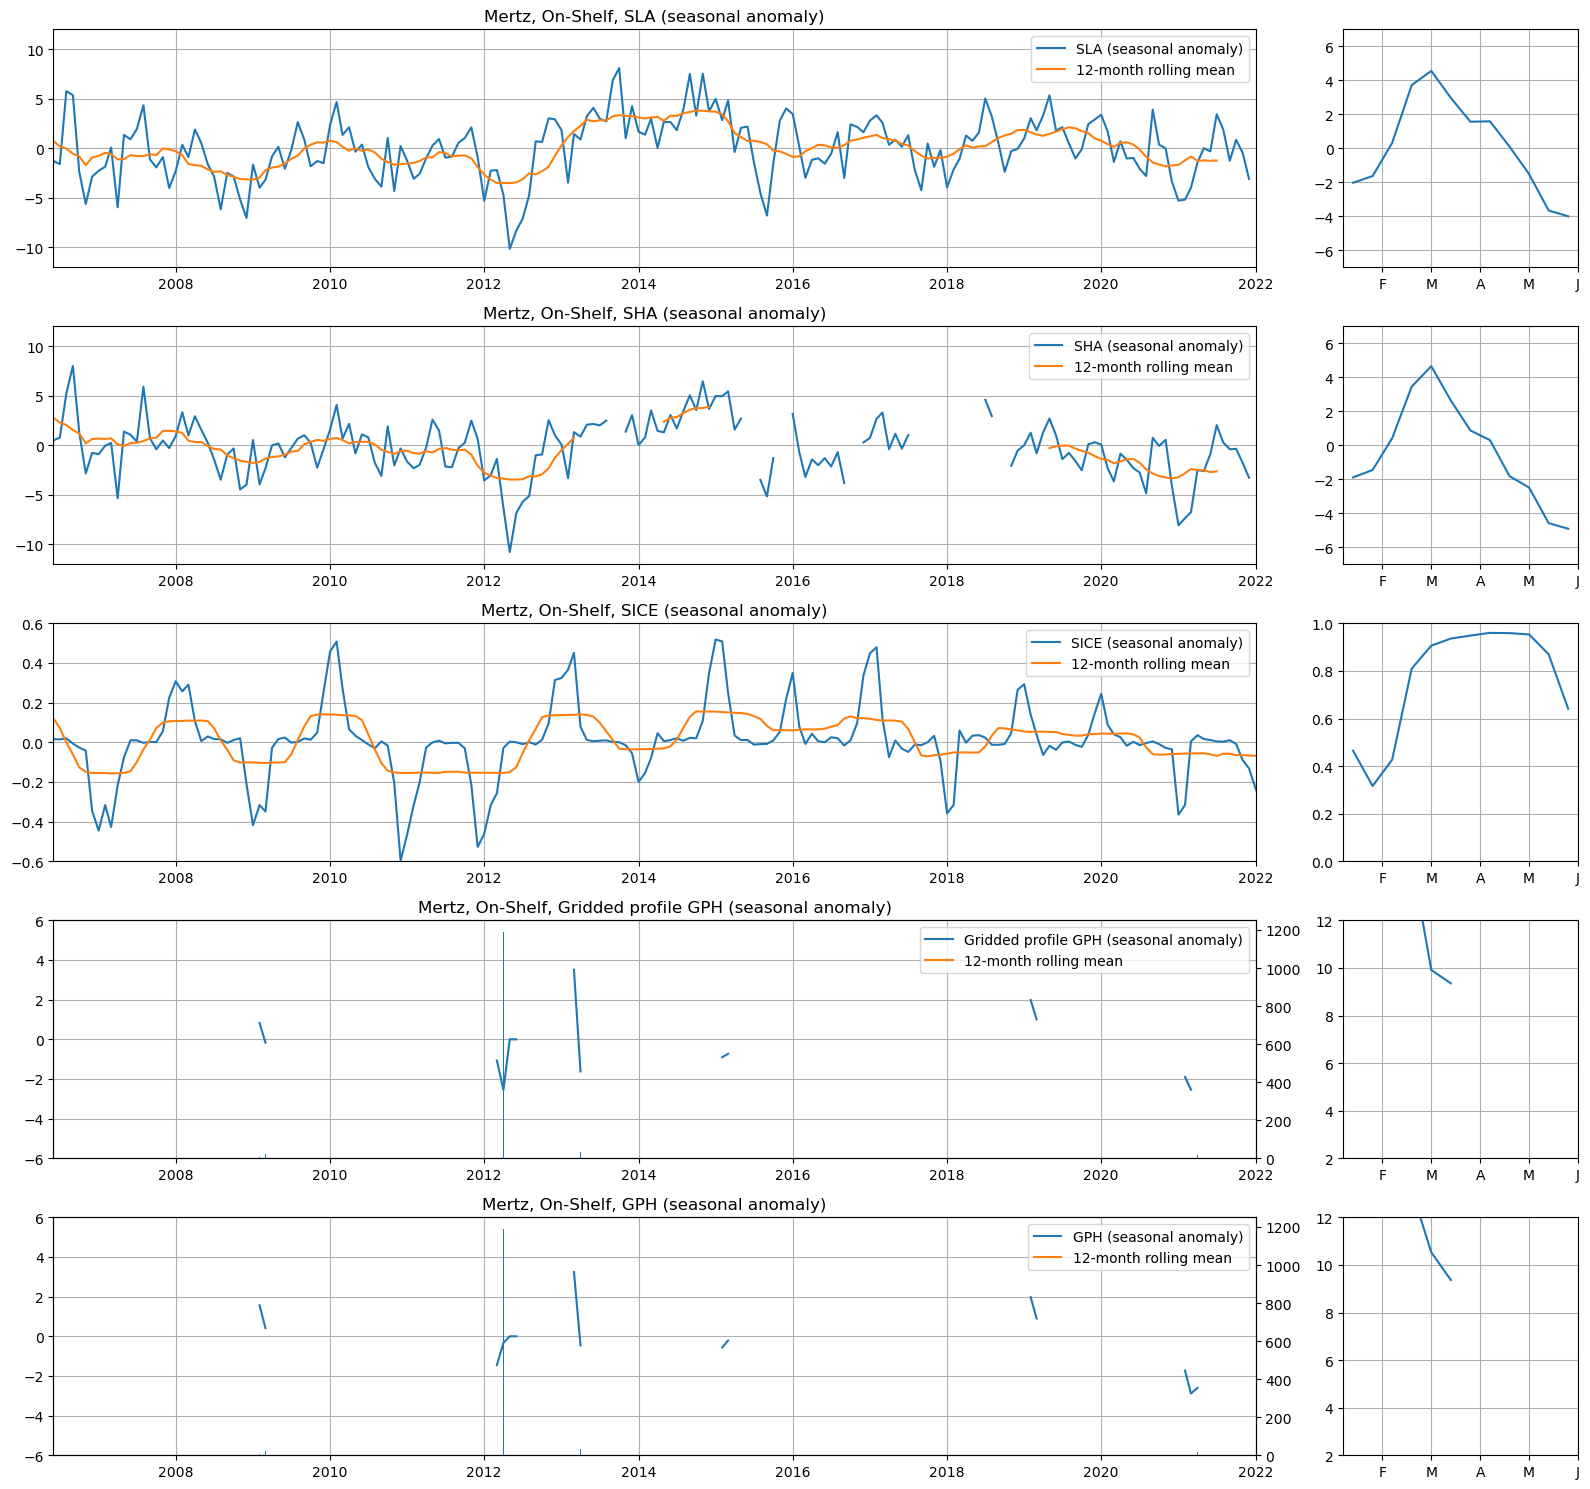

In [35]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
fig = plt.figure(figsize=(16,15))
axs=[]

gs = fig.add_gridspec(5,5)

def add_row_anom(n,var,varname,title,extent,shelf=False,ylim=[-12,12],ylim_cmt=[-7,7]):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)


    if varname == 'GPH':
        da = var
    else:
        da = region.crop_da(var).mean(['latitude','longitude'])

    ax = axs[(n*2)]

    cmt = da.groupby('time.month').mean()
    anm = da.groupby('time.month') - cmt
    varname = varname + ' (seasonal anomaly)'

    ax.plot(anm.time,anm,label=varname)
    ax.plot(anm.time,anm.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title +', '+shelf_str+'-Shelf, ' + varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2006,6,1),pd.Timestamp(2022,1,1)])
    ax.grid()

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])


add_row_anom(0,sha_gph_.ssha,'SLA','Mertz',extent,shelf=True)
add_row_anom(1,sha_gph_.sha,'SHA','Mertz',extent,shelf=True)
add_row_anom(2,sice,'SICE','Mertz',extent,shelf=True,ylim=[-0.6,0.6],ylim_cmt=[0,1])
add_row_anom(3,sha_gph_.profile_gph*100,'Gridded profile GPH','Mertz',extent,shelf=True,ylim_cmt=[2,12],ylim=[-6,6])
add_row_anom(4,profile_gph_ungridded*100,'GPH','Mertz',extent,shelf=True,ylim_cmt=[2,12],ylim=[-6,6])

axs[6].twinx().bar(sha_gph_.time,sha_gph_.profile_cnt.sum(['latitude','longitude']))
axs[8].twinx().bar(profile_gph_ungridded.time,meop.df.dropna().gph.groupby(pd.Grouper(freq='MS')).count())


plt.tight_layout()
print('Rendering..')


In [38]:
months = meop.df.dropna().gph.groupby(pd.Grouper(freq='MS')).count() > 200

In [87]:
meop.df.dropna().gph.groupby(pd.Grouper(freq='MS')).mean()[months].index[0]

Timestamp('2009-03-01 00:00:00')

In [41]:
t = pd.Timestamp(2000,1,1)
t + pd.DateOffset(months=1)

Timestamp('2000-02-01 00:00:00')

In [88]:
def radial_profile(ax,meop,ts):
    #ts = pd.Timestamp(year,month,1)
    profiles = meop.filter_profiles(ts,ts+pd.DateOffset(months=1))
    profiles_df = meop.df[(meop.df.index > ts) & (meop.df.index < ts+pd.DateOffset(months=1))]

    im=pfns.sp(ax=ax[0],da=sha_gph_.ssha.sel(time=ts),extent=extent,vmax=10)
    ax[0].scatter(profiles_df.longitude, profiles_df.latitude, transform=ccrs.PlateCarree())
    ax[0].set_title(ts)
    cbar = plt.colorbar(im, label='SLA')


    # fig, ax = plt.subplots(figsize=(6,4), subplot_kw={'projection':ccrs.Mercator()})
    # pfns.sp(ax=ax,,extent=extent,vmax=10,cmap='viridis')
    # im=ax.scatter(profiles_df.longitude, profiles_df.latitude, [1 for t in profiles_df.index], profiles_df.gph*100, transform=ccrs.PlateCarree(),vmin=-5,vmax=25)
    # ax.set_title(ts)

    for profile in profiles:
        im=ax[1].scatter(profile.ds.salinity,profile.ds.temperature,5,profile.ds.pressure,vmin=0,vmax=500)
    ax[1].set_ylim([-2.4,1.4])
    ax[1].set_xlim([33,34.75])
    cbar = plt.colorbar(im, label='PRES')

    plt.tight_layout()



range(0, 17)

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

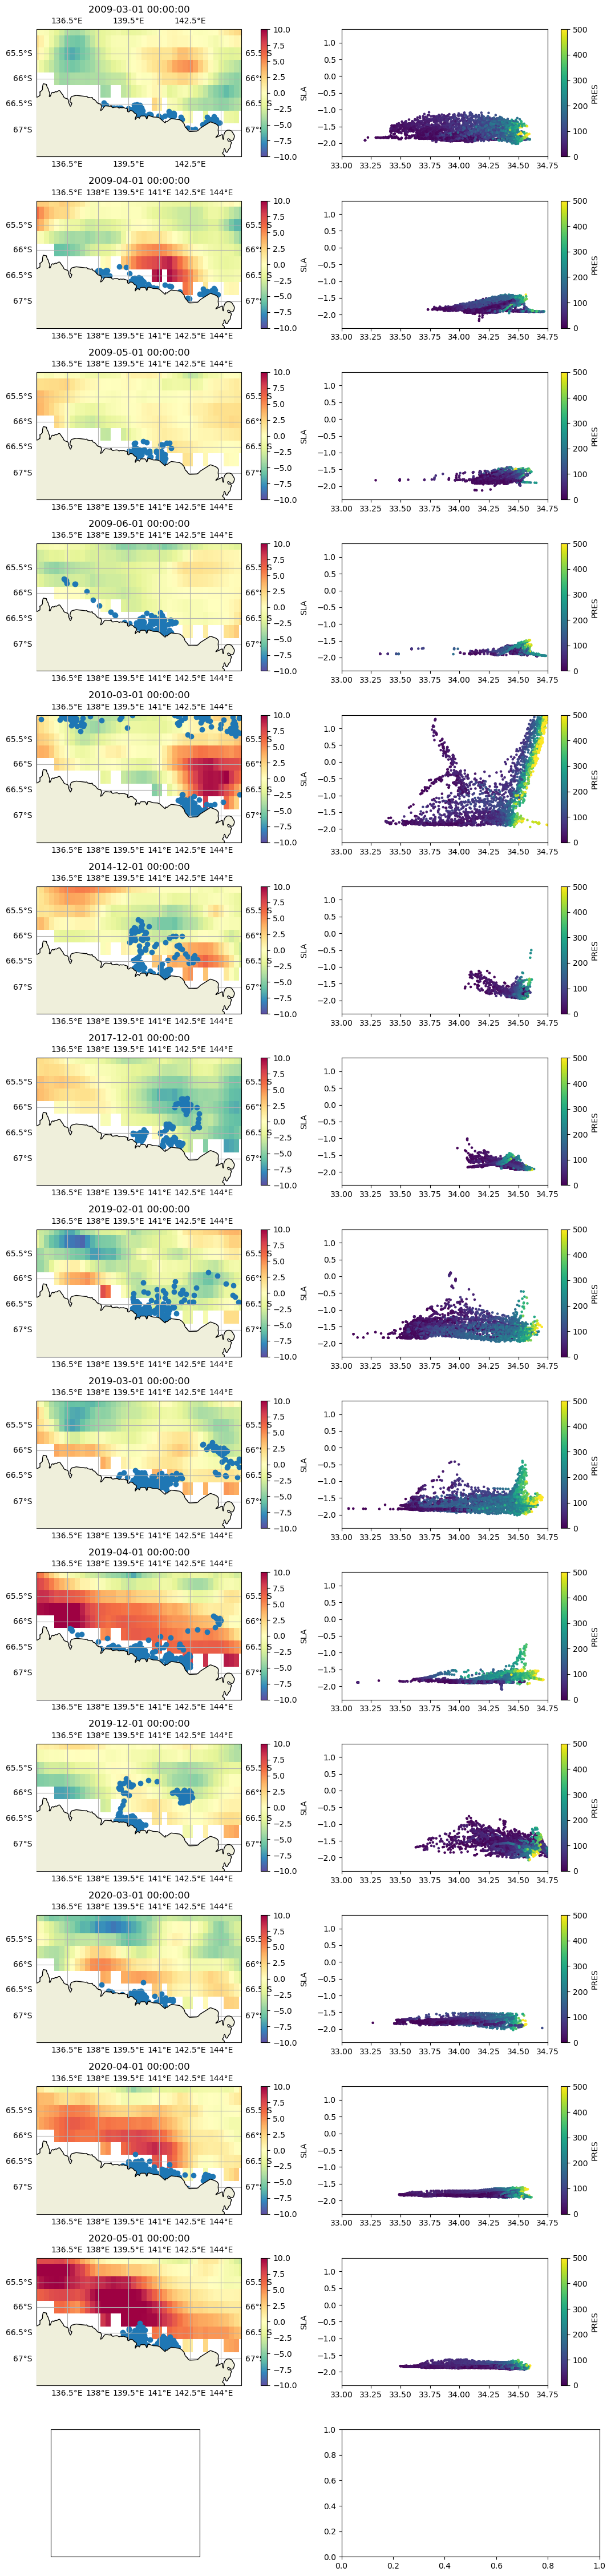

In [91]:
n=17
fig = plt.figure(figsize=(12,3*n))
axs=[]

gs = fig.add_gridspec(n,2,width_ratios=[3,2])

for i in np.arange(n):
    ts = meop.df.dropna().gph.groupby(pd.Grouper(freq='MS')).mean()[months].index[i]
    axs.append(fig.add_subplot(gs[i,0],projection=ccrs.Mercator()))
    axs.append(fig.add_subplot(gs[i,1]))
    radial_profile([axs[i*2],axs[(i*2)+1]],meop,ts)

In [ ]:
def coastal_transects(ax,meop,ts):

    profiles = meop.filter_profiles(ts,ts+pd.DateOffset(months=1))
    profiles_df = meop.df[(meop.df.index > ts) & (meop.df.index < ts+pd.DateOffset(months=1))]

    im=pfns.sp(ax=ax[0],da=sha_gph_.ssha.sel(time=ts),extent=extent,vmax=10)
    ax[0].scatter(profiles_df.longitude, profiles_df.latitude, transform=ccrs.PlateCarree())
    ax[0].set_title(ts)
    cbar = plt.colorbar(im, label='SLA')

    ds = xr.merge([p.ds for p in profiles])
    ax[1].contourf(ds.longitude,ds.pressure,ds.temperature)

    plt.tight_layout()